In [4]:
import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
import pandas as pd

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data_path = "/home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham"
sdata = sd.read_zarr(data_path)
sdata

/tmp/ipykernel_65829/1828072172.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(data_path)
/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

In [7]:
from skimage import io as skio
from skimage.measure import regionprops_table #library for calculate centroids

In [8]:
#read and upload mask
mask= skio.imread("/home/stefano/Documents/Spatial-Transcriptomic/images/blocco1_sham_masks.tif")

In [9]:
bin_shapes = sdata.shapes['intissue_008um']
#Estrai le coordinate pixel REALI dei bin sfruttando i centroidi della geometria
# Questo estrae i punti fisici (X, Y) nello spazio reale dell'immagine
centroids = bin_shapes.geometry.centroid
x_pixel = centroids.x.values.astype(int)
y_pixel = centroids.y.values.astype(int)

In [6]:
#see how many pixels a bins cover
#for the x_pixel
for i in range(len(x_pixel[:10])):
    if i != 0:
        diff = x_pixel[i] - x_pixel[i-1]
        print(diff)

-25
-25
-26
-25
-25
-26
-25
-25
-26


In [10]:
print(f"Dimensioni Maschera Cellpose: Altezza (Y) = {mask.shape[0]}, Larghezza (X) = {mask.shape[1]}")
print(f"Range X dei centroidi: min = {x_pixel.min()}, max = {x_pixel.max()}")
print(f"Range Y dei centroidi: min = {y_pixel.min()}, max = {y_pixel.max()}")
#As we can see cellpose mask start from 0,0 coordinate, x_pixels and y_pixels no we need to fix it
x_global = centroids.x.values
y_global = centroids.y.values
mask_height, mask_width = mask.shape  # Prende automaticamente 7000 e 16168

x_pixel = (x_global - x_global.min()) * (mask_width / (x_global.max() - x_global.min() + 1))
y_pixel = (y_global - y_global.min()) * (mask_height / (y_global.max() - y_global.min() + 1))
x_pixel = x_pixel.astype(int)
y_pixel = y_pixel.astype(int)

Dimensioni Maschera Cellpose: Altezza (Y) = 7000, Larghezza (X) = 16168
Range X dei centroidi: min = 647, max = 14853
Range Y dei centroidi: min = 7987, max = 14943


In [11]:
x_global = centroids.x.values
y_global = centroids.y.values
mask_height, mask_width = mask.shape  # Prende automaticamente 7000 e 16168

#Applica la normalizzazione spaziale 
# Sottraiamo il minimo per azzerare l'offset e scaliammo sulle dimensioni della maschera

x_pixel = (x_global - x_global.min()) * (mask_width / (x_global.max() - x_global.min() + 1))
y_pixel = (y_global - y_global.min()) * (mask_height / (y_global.max() - y_global.min() + 1))
x_pixel = x_pixel.astype(int)
y_pixel = y_pixel.astype(int)

print(f"the area of the image covered by x_pixel x y_pixel is {x_pixel.max()} x {y_pixel.max()}")
#as we can see is very similar to the dimension of the cellpose mask

the area of the image covered by x_pixel x y_pixel is 16166 x 6998


In [25]:
np.min(x_global-x_global.max())

np.float64(-14206.55856060512)

In [12]:
#tabella delle annotazioni con info trascrizionali
adata_bins = sdata.tables['filtered']
print(adata_bins)

# Verifica di sicurezza: il numero di geometrie deve coincidere con le righe dell'AnnData
assert len(bin_shapes) == adata_bins.n_obs, "Discrepanza tra il numero di shapes e i bin"

AnnData object with n_obs × n_vars = 95232 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'sample_id', 'in_treatment', 'GFP_value'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


In [104]:
mask[341,3395]

np.uint16(6)

In [13]:
#Mappatura dei bin sulla maschera di Cellpose
fiber_assignments = np.zeros(adata_bins.n_obs, dtype=int)

#Filtro di sicurezza per evitare indici fuori scala (es. clipping sui bordi)
valid_coords = (x_pixel >= 0) & (x_pixel < mask_width) & (y_pixel >= 0) & (y_pixel < mask_height)

#Assegna l'ID della fibra basandoti sulla coordinata pixel corretta (Y=righe, X=colonne)
fiber_assignments[valid_coords] = mask[y_pixel[valid_coords], x_pixel[valid_coords]]

#Salva l'informazione nell'AnnData originale così non perdi il tracciamento
adata_bins.obs['assigned_fiber'] = fiber_assignments

In [14]:
#Isola i bin che sono caduti dentro una fibra segmentata (ID > 0)
adata_inside_fibers = adata_bins[adata_bins.obs['assigned_fiber'] > 0]

print(f"Bins totali nel dataset: {len(adata_bins)}")
print(f"Bins mappati dentro le fibre muscolari: {len(adata_inside_fibers)}")

Bins totali nel dataset: 95232
Bins mappati dentro le fibre muscolari: 52162


In [11]:
#see how many bins are present in the fiber 47
adata_inside_fibers.obs[adata_inside_fibers.obs['assigned_fiber']==47]

,in_tissue,array_row,array_col,location_id,region,sample_id,in_treatment,GFP_value,assigned_fiber
s_008um_00365_00456-1,1,365,456,293383,intissue_008um,sham,False,6.0,47
s_008um_00365_00457-1,1,365,457,293384,intissue_008um,sham,False,6.0,47
s_008um_00365_00458-1,1,365,458,293385,intissue_008um,sham,False,5.0,47
s_008um_00365_00459-1,1,365,459,293386,intissue_008um,sham,False,4.0,47
s_008um_00366_00456-1,1,366,456,294163,intissue_008um,sham,False,12.0,47
s_008um_00366_00457-1,1,366,457,294164,intissue_008um,sham,False,12.0,47
s_008um_00366_00458-1,1,366,458,294165,intissue_008um,sham,False,12.0,47
s_008um_00366_00459-1,1,366,459,294166,intissue_008um,sham,False,12.0,47
s_008um_00366_00460-1,1,366,460,294167,intissue_008um,sham,False,12.0,47
s_008um_00367_00456-1,1,367,456,294957,intissue_008um,sham,False,13.0,47


In [12]:
sdata.tables['filtered']

AnnData object with n_obs × n_vars = 95232 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'sample_id', 'in_treatment', 'GFP_value', 'assigned_fiber'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

# Prepare the data for the annotation
The annotation will be done in R with rctd method, that method use a spatial experiment object which requires for its construction in that case specifical data:
* **fiber expression matrix** : a matrix which have for row the fiber and for columns the genes, each fibers has an expressione defined by bins inside the fiber. The assignment of the bin to the segmented fiber was done previously in that notebook.

* **centroid fiber matrix**: a matrix of with spatial coordinate of centroid of each segmented fiber, each centroid are obtained calculating the mean coordinates positions using all the bins belonging to their respective fiber.

In [15]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix, coo_matrix
from skimage.measure import regionprops_table

## fiber expression matrix

In [16]:
#THE FOLLOWING COMMENTED CODE IS USED TO CREATE THE FIBER EXPRESSION MATRIX BUT SINCE THE DATA SET IS VERY BIG IT EASIILY
#SATURATE THE RAM(16GB) OF MY PC, THANKS TO AI I WAS ABLE TO PRODUCE MORE EFFICENT CODE THE ONLY PROBLEM IS WHICH
#IS LESS READABLE AND UNDERSTANDABLE OF THE ONE BELOW ANYWAY IT WORKS.
"""""
#Crea matrice Fibre x Geni
expression_df = pd.DataFrame(
    adata_inside_fibers.X.toarray() if hasattr(adata_inside_fibers.X, "toarray") else adata_inside_fibers.X,
    index = adata_inside_fibers.obs['assigned_fiber'], #assign the rows names (fibers)
    columns = adata_inside_fibers.var_names #assign columns names (genes)
)

#sum for each fiber sum all the bin expression belonging to that fiber
fiber_matrix_df = expression_df.groupby(level=0).sum() #sum all the rows which have the same assigned fiber id
"""

#OPTIMIZED CODE

# 1. Recuperiamo gli ID delle fibre dai metadati dei bin
fiber_labels = adata_inside_fibers.obs['assigned_fiber'].values

# 2. Troviamo gli ID univoci delle fibre
unique_fibers = np.unique(fiber_labels)

# Creiamo una mappa per convertire l'ID della fibra in un indice di riga (0, 1, 2...)
fiber_to_idx = {fiber: idx for idx, fiber in enumerate(unique_fibers)}
row_indices = np.array([fiber_to_idx[f] for f in fiber_labels])

# 3. Costruiamo una matrice di design sparsa (Bin x Fibre)
# Questa matrice dirà matematicamente a quali fibre appartengono i bin
n_bins = adata_inside_fibers.n_obs
n_fibers = len(unique_fibers)

# Matrice binaria indicizzatrice
design_matrix = coo_matrix(
    (np.ones(n_bins), (row_indices, np.arange(n_bins))),
    shape=(n_fibers, n_bins)
).tocsr()

# 4. IL TRUCCO GEOMETRICO: Moltiplicazione tra matrici sparse
# Moltiplicando la matrice di design (Fibre x Bin) per la matrice dei conteggi (Bin x Geni)
# otteniamo DIRETTAMENTE la somma dei geni per ogni fibra, senza mai occupare RAM inutile.
print("Aggregazione sparsa in corso... Sarà istantanea.")
fiber_expression_sparse = design_matrix @ adata_inside_fibers.X

# 5. Creiamo l'oggetto AnnData finale direttamente in formato sparso
adata_fibers = ad.AnnData(
    X=csr_matrix(fiber_expression_sparse),
    var=pd.DataFrame(index=adata_inside_fibers.var_names),
    obs=pd.DataFrame(index=unique_fibers.astype(str))
)
adata_fibers.obs_names.name = 'fiber_id'

# 6. Salva nel tuo oggetto SpatialData
sdata.tables["table_fibers"] = adata_fibers

print("Fatto! Aggregazione completata senza saturare la RAM.")
print(sdata.tables["table_fibers"])


Aggregazione sparsa in corso... Sarà istantanea.
Fatto! Aggregazione completata senza saturare la RAM.
AnnData object with n_obs × n_vars = 2602 × 32285


In [25]:
sdata.tables

{'square_008um': AnnData object with n_obs × n_vars = 95514 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'final_table': AnnData object with n_obs × n_vars = 95514 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'in_treatment', 'to_discard'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'square_016um': AnnData object with n_obs × n_vars = 44363 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'filtered': AnnData object with n_obs × n_vars = 95232 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'sample_id', 'in_treatment', 'GFP_value', 'assigned_fiber'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdat

In [27]:
sdata.tables['square_016um'].var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Gm1992,ENSMUSG00000089699,Gene Expression,mm10
Gm19938,ENSMUSG00000102331,Gene Expression,mm10
Gm37381,ENSMUSG00000102343,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
...,...,...,...
AC124606.1,ENSMUSG00000095523,Gene Expression,mm10
AC133095.2,ENSMUSG00000095475,Gene Expression,mm10
AC133095.1,ENSMUSG00000094855,Gene Expression,mm10
AC234645.1,ENSMUSG00000095019,Gene Expression,mm10


In [33]:
adata_fibers.var.index

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'Lypla1',
       ...
       'Gm16367', 'AC163611.1', 'AC163611.2', 'AC140365.1', 'AC124606.2',
       'AC124606.1', 'AC133095.2', 'AC133095.1', 'AC234645.1', 'AC149090.1'],
      dtype='str', length=32285)

## centroid matrix

In [28]:
#Now obtain the the centroid fiber matrix
properties = ['label', 'centroid'] #define the parameter for regionprops_table
fiber_centroids = regionprops_table(mask, properties=properties)

#convert to DataFrame
df_centroids = pd.DataFrame(fiber_centroids)


#rename the columns (remember centroid-0 = Y, centroid-1=X)
df_centroids = df_centroids.rename(
    columns={"label": "fibra_id", "centroid-0": "Y", "centroid-1": "X"}
)

#reorder the columns
df_centroids = df_centroids[['fibra_id', 'X', 'Y']]

#set the fiber_id as index
df_centroids = df_centroids.set_index('fibra_id')


In [66]:
df_centroids

,X,Y
fibra_id,,
1,3485.785714,10.833333
2,6953.762712,248.847458
3,8254.489170,285.774368
4,6653.664049,343.126527
5,6800.630298,362.887755
...,...,...
2632,9905.366071,6646.348214
2633,5940.703252,6597.508130
2634,5754.168132,6619.434066


In [29]:
#since there is a mismatch between the fiber expr matrix and centroid matrix we need to select only the fibers 
#which belong in both datasets
id_segmented_fibers = sdata.tables['table_fibers'].obs.index
id_segmented_fibers = [int(el) for el in id_segmented_fibers] #convert str to int beca
df_filtred_centroids = df_centroids.loc[id_segmented_fibers]

In [18]:
df_filtred_centroids

,X,Y
fibra_id,,
24,1079.694842,779.815186
27,1808.986744,775.273065
28,1922.514333,800.604741
29,2015.193567,797.757310
30,1626.995376,788.591149
...,...,...
2632,9905.366071,6646.348214
2633,5940.703252,6597.508130
2634,5754.168132,6619.434066


In [30]:
#save the centroid in the spatial data object
sdata.tables['table_fibers'].obs['X'] = df_filtred_centroids['X'].values
sdata.tables['table_fibers'].obs['Y'] = df_filtred_centroids['Y'].values

## create object for exportation in R
now create an AnnData object which cotain fiber expr matrix and centroid matrix. We will use that object to perform rctd analysis in R

In [36]:
# 1. Estrai gli ID delle fibre come stringhe standard di Python ('1', '2', '3'...)
id_fibre_stringhe = [str(int(x)) for x in sdata.tables['table_fibers'].obs.index]

# 2. Forza Pandas a creare un indice di tipo 'object' (che usa stringhe Python pure, NON Arrow)
obs_pure = pd.DataFrame(
    index=pd.Index(id_fibre_stringhe, dtype=object)
)
obs_pure.index.name = "fiber_id" 

# 3. Incolla i centroidi (con .values per sicurezza)
obs_pure["x"] = df_filtred_centroids["X"].values
obs_pure["y"] = df_filtred_centroids["Y"].values

# 4. Fai la stessa cosa per i geni: stringhe pure in indice object
nomi_geni_stringhe = [str(g) for g in sdata.tables['table_fibers'].var.index]
var_pure = pd.DataFrame(
    index=pd.Index(nomi_geni_stringhe, dtype=object)
)

# 5. Crea l'AnnData. Ora non darà nessun ImplicitModificationWarning perché l'indice è già di stringhe!
adata_clean = ad.AnnData(X=fiber_expression_sparse, obs=obs_pure, var=var_pure)

# 6. Salva direttamente nella cartella corrente per evitare ogni problema di percorso
#adata_clean.write_h5ad('fibers_visium_hd.h5ad')

In [27]:
fiber_expression_sparse


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3250142 stored elements and shape (2602, 32285)>

In [23]:
obs_pure

,x,y
fiber_id,,
24,1079.694842,779.815186
27,1808.986744,775.273065
28,1922.514333,800.604741
29,2015.193567,797.757310
30,1626.995376,788.591149
...,...,...
2632,9905.366071,6646.348214
2633,5940.703252,6597.508130
2634,5754.168132,6619.434066


# RCTD
now make the annotation through the rctd model

In [31]:
from rctd import Reference, run_rctd, RCTDConfig
from scipy.io import mmread
import scanpy as sc

## preparation of the reference data

In [32]:
#build reference with data coming from single-cell experiments
# 1. Carica la matrice sparsa e i metadati
mat = mmread("/home/stefano/Documents/Spatial-Transcriptomic/annotation/ref_counts.mtx").tocsr() # Legge la matrice dei conteggi
genes = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/ref_genes.txt", header=None)[0].values
barcodes = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/ref_barcodes.txt", header=None)[0].values
metadata = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/ref_metadata.csv", index_col=0)


In [33]:
# 2. Ricostruisci l'AnnData (Rctd vuole i Geni come colonne e le Cellule come righe, quindi trasponiamo se necessario)
# Di norma writeMM salva in formato Geni x Cellule, quindi facciamo la trasposta (.T) per Python
adata_ref = sc.AnnData(X=mat.T, obs=metadata)
adata_ref.obs_names = barcodes
adata_ref.var_names = genes

# 3. Controlla che sia tutto ok
print(adata_ref)


AnnData object with n_obs × n_vars = 18563 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'dataset', 'cond

In [34]:
reference = Reference(adata_ref, cell_type_col='subclusters')
print(f"Reference profiles: {reference.profiles.shape}")
print(f"Cell types: {reference.cell_type_names}")

Reference profiles: (32285, 15)
Cell types: ['Endothelial', 'FAPs', 'Immune_Cells', 'MuSC', 'Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIx_IIa', 'Myonuclei_IIx_IIb', 'Myonuclei_MTJ', 'Myonuclei_NMJ', 'Myonuclei_Trim63', 'Nervous_System', 'Pericyte', 'Smooth_Muscular', 'Tenocyte']


## Run RCTD

In [1]:
from rctd import SPOT_CLASS_NAMES
import time
import rctd
import torch

In [46]:
class_labels = dict(enumerate(SPOT_CLASS_NAMES))
class_labels

{0: 'reject', 1: 'singlet', 2: 'doublet_certain', 3: 'doublet_uncertain'}

In [37]:
# Sblocca il bug di compilazione forzando PyTorch a non usare torch.compile
# 1. Spegne totalmente il compilatore Dynamo/Inductor a livello globale
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"



# 3. Forza la disattivazione del JIT anche lato codice torch
torch._dynamo.config.disable = True

_config = RCTDConfig(UMI_min=1, UMI_min_sigma=1)
_t0 = time.time()
result_multi = run_rctd(adata_clean, reference, mode='multi', config=_config)
t_multi = time.time() - _t0
print(f'Multi mode: {t_multi:.1f}s')
print(f'Types per bead: min={result_multi.n_types.min()}, max={result_multi.n_types.max()}')

Gene lists: bulk=3261, reg=2029 (from 32245 common)
Fitting bulk platform effects...
Using 2029 DE genes for pixel-level fitting
Estimating sigma...
Chosen sigma: 0.28 (17.7s)
Auto batch size: 10000
Running in multi mode...
Multi mode: 374.5s
Types per bead: min=1, max=4


In [38]:
#using the results of rctd create a dataframe with shape: fiber x cells_type, with elements corrsponding to the probability of a specific fiber to belonging to a cells type
cellular_type=reference.cell_type_names #define the possible cellular type 
fiber_id = adata_clean.obs_names 

# create an array with row equal to fiber id and columns equal to genes
weights_df = pd.DataFrame(
    result_multi.weights, 
    index=fiber_id, 
    columns=cellular_type
)

# Ora puoi guardare le prime righe!
print(weights_df.head())

          Endothelial      FAPs  Immune_Cells      MuSC  Myonuclei_IIb  \
fiber_id                                                                 
24           0.049892  0.191792      0.004338  0.000037       0.064057   
27           0.010857  0.000053      0.000053  0.000053       0.763430   
28           0.000053  0.000053      0.000053  0.000053       0.737852   
29           0.000053  0.000053      0.000053  0.000053       0.753082   
30           0.030440  0.000037      0.000037  0.000037       0.618517   

          Myonuclei_IIx  Myonuclei_IIx_IIa  Myonuclei_IIx_IIb  Myonuclei_MTJ  \
fiber_id                                                                       
24             0.000037           0.000037           0.000037       0.541427   
27             0.000053           0.000053           0.069665       0.071889   
28             0.000053           0.000053           0.076738       0.074799   
29             0.000053           0.000053           0.132464       0.015286   
3

In [97]:
#since rctd requires time to run, save the weight_df in local
#weights_df.to_parquet('/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_weights.parquet', index=True) # save

#for upload
weights_df = pd.read_parquet("/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_weights.parquet")

## Analysis of the results

In [115]:
dominant_cell_type = weights_df.idxmax(axis=1) #return the index of the maximum column value for each row

#identificate all fibers which has all estimated weights equal to 0
zero_row = weights_df.sum(axis=1) == 0

#assign to that fibers a neutral class, "Unassigned"
dominant_cell_type[zero_row] = "Unassigned"


#map the name of each celltype
unique_cell_types = weights_df.columns.to_list()
type_to_id = {name: i+1 for i,name in enumerate(unique_cell_types)}
type_to_id["Unassigned"] = 0

#associate to each fiber its corresponding ID
fiber_to_id = dominant_cell_type.map(type_to_id).to_dict()

In [ ]:
#Verify if there are unassigned fibers
for fiber_id, cell_type in fiber_to_id.items():
    if cell_type == 0:
        print(fiber_id)

In [ ]:
'''
#the code is to assign the cell type label to each segmented fiber, the problem is which is slow due to the high dimensionality of the dataset

#the idea is to create a mask which allow me interactive visualization in napari, each fiber has specific label corresponding to its dominant cellular population
cell_type_mask = np.zeros_like(mask) #create a mask which has the same shape of the mask initially used to annotate the fibers (the ones created by cellpose)

for fiber_name, cell_id in fiber_to_id.items():
    fiber_id = int(fiber_name) #since previously fiber id was converted is str we now convert it in a number in order to allow selection of pixels, see below
    cell_type_mask[mask == fiber_id] = cell_id #assign to the selected pixels the cell_id obtained from rctd analysis
'''

#ALTERNATIVE AND FASTER CODE
max_id = mask.max() #max fiber label of the original mask
translator = np.zeros(max_id +1, dtype=np.int32) 

for fiber_name, cell_id in fiber_to_id.items():
    fiber_id = int(fiber_name)
    if fiber_id <= max_id:
        translator[fiber_id] = cell_id #assign to each fiber_id the correspondent cell_type

cell_type_mask = translator[mask] #assign to each element of the original mask the correspondent cell_id

In [114]:
fiber_to_id.items()

dict_items([('24', 9), ('27', 5), ('28', 5), ('29', 5), ('30', 5), ('31', 5), ('32', 5), ('34', 5), ('37', 5), ('38', 5), ('39', 5), ('40', 5), ('41', 6), ('42', 5), ('43', 5), ('45', 9), ('46', 5), ('47', 5), ('48', 5), ('49', 5), ('51', 5), ('52', 5), ('53', 5), ('54', 5), ('55', 5), ('56', 5), ('57', 5), ('58', 5), ('59', 5), ('60', 5), ('61', 6), ('62', 5), ('63', 5), ('64', 6), ('65', 5), ('66', 5), ('67', 5), ('68', 5), ('69', 6), ('70', 6), ('71', 5), ('72', 5), ('73', 5), ('74', 5), ('75', 5), ('76', 5), ('77', 5), ('78', 5), ('79', 5), ('80', 5), ('81', 5), ('82', 5), ('83', 5), ('84', 5), ('85', 5), ('86', 5), ('87', 5), ('88', 5), ('89', 5), ('90', 5), ('91', 5), ('92', 5), ('93', 5), ('94', 5), ('95', 5), ('96', 6), ('97', 5), ('98', 5), ('99', 7), ('100', 5), ('101', 5), ('102', 5), ('103', 6), ('104', 5), ('105', 5), ('106', 5), ('107', 5), ('108', 5), ('110', 5), ('111', 5), ('112', 5), ('113', 5), ('114', 5), ('115', 5), ('116', 6), ('117', 5), ('118', 5), ('119', 5), (

In [94]:
#export mask
import tifffile as tiff

# Convertiamo la maschera in un tipo di dato intero efficiente (es. 16-bit)
# uint16 supporta numeri da 0 a 65535, perfetto per i tuoi ID popolazione
rctd_mask_uint16 = cell_type_mask.astype('uint16')

# Esporta il file TIFF sul tuo disco
tiff.imwrite('maschera_popolazioni_rctd.tiff', rctd_mask_uint16)
print("Maschera esportata con successo in formato TIFF!")

Maschera esportata con successo in formato TIFF!


# Prove di verifica
Verify if bins are correctly mapped in terms of spatial coordinates inside the segmentates fibers

In [ ]:
# 1. Definiamo la normalizzazione corretta (quella che ha funzionato per l'aggregazione)
mask_height, mask_width = mask.shape

# Ricalcoliamo i pixel normalizzati partendo dai centroidi globali nativi
x_pixel_normalized = (x_global - x_global.min()) * (mask_width / (x_global.max() - x_global.min() + 1))
y_pixel_normalized = (y_global - y_global.min()) * (mask_height / (y_global.max() - y_global.min() + 1))

x_pixel_normalized = x_pixel_normalized.astype(int)
y_pixel_normalized = y_pixel_normalized.astype(int)


# 2. Scegliamo la fibra per il test (es. la fibra 47)
test_fiber_id = 47

# 3. Trova dove si trova la fibra nella maschera di Cellpose
y_indices, x_indices = np.where(mask == test_fiber_id)

if len(x_indices) == 0:
    raise ValueError(f"La fibra {test_fiber_id} non è presente nella maschera. Scegli un altro ID.")

print(f"--- [MASCHERA CELLPOSE] Fibra {test_fiber_id} ---")
print(f"La fibra occupa {len(x_indices)} pixel nella maschera.")
print(f"Bounding Box nei pixel dell'immagine: X=[{x_indices.min()}, {x_indices.max()}], Y=[{y_indices.min()}, {y_indices.max()}]")


# 4. Estraiamo i bin che la pipeline ha assegnato alla test_fiber_id

# Troviamo gli indici posizionali corrispondenti nell'oggetto originario per pescare i pixel corretti
assigned_indices = np.where(sdata.tables["filtered"].obs['assigned_fiber'] == test_fiber_id)[0]

# Prendiamo i pixel normalizzati associati a questi bin
fiber_bins_x = x_pixel_normalized[assigned_indices]
fiber_bins_y = y_pixel_normalized[assigned_indices]

print(f"\n--- [PIPELINE BINS NORMALIZZATI] Fibra {test_fiber_id} ---")
print(f"Numero di bin di Visium HD mappati dentro la fibra: {len(fiber_bins_x)}")


# 5. IL CHECK CRUCIALE
# Verifichiamo se ogni pixel (X, Y) normalizzato del bin cade su un pixel della maschera che vale 49
correct_mappings = 0
incorrect_mappings = 0

for x, y in zip(fiber_bins_x, fiber_bins_y):
    # Controllo di sicurezza per evitare indici fuori matrice
    if 0 <= x < mask_width and 0 <= y < mask_height:
        if mask[y, x] == test_fiber_id:
            correct_mappings += 1
        else:
            incorrect_mappings += 1
    else:
        incorrect_mappings += 1

print(f"\n--- REQUISITI DI VALIDAZIONE ---")
print(f"Bin posizionati correttamente: {correct_mappings}")
print(f"Bin fuori posizione: {incorrect_mappings}")

if incorrect_mappings == 0 and correct_mappings > 0:
    print(f"\n✅ VALIDAZIONE RIUSCITA: Il 100% dei bin estratti cade esattamente sopra la fibra {test_fiber_id}.")
else:
    print(f"\n⚠️ Sfasamento rilevato. Verifica se i bin corretti sono vicini ai bordi della fibra o totalmente disallineati.")

--- [MASCHERA CELLPOSE] Fibra 47 ---
La fibra occupa 14080 pixel nella maschera.
Bounding Box nei pixel dell'immagine: X=[7452, 7591], Y=[852, 999]

--- [PIPELINE BINS NORMALIZZATI] Fibra 47 ---
Numero di bin di Visium HD mappati dentro la fibra: 17

--- REQUISITI DI VALIDAZIONE ---
Bin posizionati correttamente: 17
Bin fuori posizione: 0

✅ VALIDAZIONE RIUSCITA: Il 100% dei bin estratti cade esattamente sopra la fibra 47.


# Analysis inside the segmented fibers

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#want to analyze the fiber labeled as 47
adata_fiber_47 = adata_inside_fibers[adata_inside_fibers.obs['assigned_fiber']==47]

#see the gene expression inside the fiber
adata_fiber_47.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1073 stored elements and shape (17, 32285)>

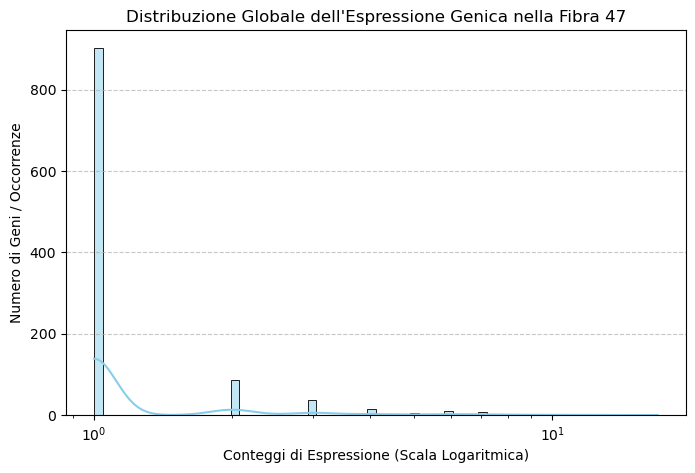

In [27]:
# Try to visualize the expression of genes inside the fiber
counts = adata_fiber_47.X.toarray()
counts = counts[counts>0] #consider only genes which are expressed

#plot the distribution of the expressed genes
plt.figure(figsize=(8, 5))
sns.histplot(counts, kde=True, log_scale=True, color='skyblue')
plt.title(f"Distribuzione Globale dell'Espressione Genica nella Fibra {47}")
plt.xlabel("Conteggi di Espressione (Scala Logaritmica)")
plt.ylabel("Numero di Geni / Occorrenze")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix, coo_matrix

In [ ]:
''' 
# Try to create a DF which have the sum of all transcripts inside the segmented fibers
counts_matrix = adata_inside_fibers.X.toarray() #convert the sparse matrix into array

df_counts = pd.DataFrame(counts_matrix, columns=adata_inside_fibers.var_names) #create a Pandas DF
df_counts['assigned_fiber'] = adata_inside_fibers.obs['assigned_fiber'].values #add label fiber column
df_fibers_genes = df_counts.groupby('assigned_fiber').sum() #sum the values (by columns) of all rows which share the same fiber label

print(df_fibers_genes.head())

THIS OPERATIONS REQUIRES A LOT OF RAM TRY TO ACHIEVE THE SAME RESULT WITH ALTERNATIVE OPERATIONS

'''
# 1. Recuperiamo gli ID delle fibre dai metadati dei bin
fiber_labels = adata_inside_fibers.obs['assigned_fiber'].values

# 2. Troviamo gli ID univoci delle fibre
unique_fibers = np.unique(fiber_labels)

# Creiamo una mappa per convertire l'ID della fibra in un indice di riga (0, 1, 2...)
fiber_to_idx = {fiber: idx for idx, fiber in enumerate(unique_fibers)}
row_indices = np.array([fiber_to_idx[f] for f in fiber_labels])

# 3. Costruiamo una matrice di design sparsa (Bin x Fibre)
# Questa matrice dirà matematicamente a quali fibre appartengono i bin
n_bins = adata_inside_fibers.n_obs
n_fibers = len(unique_fibers)

# Matrice binaria indicizzatrice
design_matrix = coo_matrix(
    (np.ones(n_bins), (row_indices, np.arange(n_bins))),
    shape=(n_fibers, n_bins)
).tocsr()

# 4. IL TRUCCO GEOMETRICO: Moltiplicazione tra matrici sparse
# Moltiplicando la matrice di design (Fibre x Bin) per la matrice dei conteggi (Bin x Geni)
# otteniamo DIRETTAMENTE la somma dei geni per ogni fibra, senza mai occupare RAM inutile.
print("Aggregazione sparsa in corso... Sarà istantanea.")
fiber_expression_sparse = design_matrix @ adata_inside_fibers.X

# 5. Creiamo l'oggetto AnnData finale direttamente in formato sparso
adata_fibers = ad.AnnData(
    X=csr_matrix(fiber_expression_sparse),
    var=pd.DataFrame(index=adata_inside_fibers.var_names),
    obs=pd.DataFrame(index=unique_fibers.astype(str))
)
adata_fibers.obs_names.name = 'fiber_id'

# 6. Salva nel tuo oggetto SpatialData
sdata.tables["table_fibers"] = adata_fibers

print("Fatto! Aggregazione completata senza saturare la RAM.")
print(sdata.tables["table_fibers"])



Aggregazione sparsa in corso... Sarà istantanea.
Fatto! Aggregazione completata senza saturare la RAM.
AnnData object with n_obs × n_vars = 2602 × 32285


In [15]:
# 1. Recuperiamo gli ID delle fibre dai metadati dei bin
fiber_labels = adata_inside_fibers.obs['assigned_fiber'].values

# 2. Troviamo gli ID univoci delle fibre
unique_fibers = np.unique(fiber_labels)

In [21]:
fiber_labels

array([  49,   54,   54, ..., 2630, 2630, 2630], shape=(52162,))

In [20]:
fiber_to_idx[4]

KeyError: 4

In [18]:
fiber_to_idx = {fiber: idx for idx, fiber in enumerate(unique_fibers)}
row_indices = np.array([fiber_to_idx[f] for f in fiber_labels])
row_indices

array([  19,   23,   23, ..., 2595, 2595, 2595], shape=(52162,))